# Relatorio de teste com logs Sysmon
Execute as celulas em ordem para gerar metricas, SHAP/LIME e o relatorio final.

In [46]:
import os
import sys
import subprocess
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import ipaddress
import joblib
import matplotlib.pyplot as plt

def ensure_package(import_name, pip_name=None):
    try:
        __import__(import_name)
        return
    except Exception:
        pkg = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

ensure_package("Evtx", "python-evtx")
ensure_package("shap")
ensure_package("lime")

from Evtx.Evtx import Evtx
import xml.etree.ElementTree as ET
import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

In [47]:
ROOT = Path("..").resolve()
MODEL_PATH = ROOT / "Train" / "modelo_ransomware.joblib"
DATASET_PATH = ROOT / "Datasets" / "LMD-2023-dataset.csv"

RANSOM_LOGS_DIR = ROOT / "RansomwaresLogs"
BENIGN_LOGS_DIR = ROOT / "ExesLogs"

assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"
assert RANSOM_LOGS_DIR.exists(), f"Ransomware logs dir not found: {RANSOM_LOGS_DIR}"
assert BENIGN_LOGS_DIR.exists(), f"Benign logs dir not found: {BENIGN_LOGS_DIR}"

rf = joblib.load(MODEL_PATH)
rf

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [50]:
import sys
import joblib
import pandas as pd

sys.path.append('..')

from parser.feature_engineering import extract_behavioral_features

df_train_raw = pd.read_csv(
    DATASET_PATH,
    low_memory=False
)

df_train_raw = df_train_raw[
    df_train_raw['Label'] != 2
].copy()

print('Extracting baseline behavioral features...')

df_train_behavioral = extract_behavioral_features(
    df_train_raw
)

drop_cols = [
    'Label',
    'ProcessKey'
]

X_train = df_train_behavioral.drop(
    columns=drop_cols,
    errors='ignore'
)

X_train = pd.get_dummies(
    X_train,
    columns=['Image']
)

feature_columns = joblib.load(
    ROOT / 'Train' / 'feature_columns.joblib'
)

X_train = X_train.reindex(
    columns=feature_columns,
    fill_value=0
)

imputer = joblib.load(
    ROOT / 'Train' / 'preprocessor.joblib'
)

X_train_scaled = pd.DataFrame(
    imputer.transform(X_train),
    columns=X_train.columns
)

print(f'Shape final: {X_train_scaled.shape}')

print('\nFeatures:')
print(X_train_scaled.columns.tolist())

2026-05-27 15:16:06,801 - INFO - Starting feature engineering


Extracting baseline behavioral features...


2026-05-27 15:17:14,307 - INFO - Extracted features for 13014 unique processes


Shape final: (13014, 17)

Features:
['total_events', 'events_per_second', 'max_events_same_second', 'num_created_processes', 'num_created_files', 'file_creation_rate', 'num_registry_modifications', 'num_network_connections', 'num_dns_queries', 'num_unique_ips', 'num_unique_ports', 'suspicious_extensions', 'unique_extensions_modified', 'critical_directory_activity', 'child_process_count', 'suspicious_command_count', 'Image_0.0']


In [59]:
import sys
import joblib
import pandas as pd

sys.path.append('..')

from parser.evtx_parser import parse_all_evtx
from parser.feature_engineering import extract_behavioral_features

print("Parsing ransomware EVTX files...")
df_ransom_raw = parse_all_evtx(RANSOM_LOGS_DIR)
df_ransom_raw["Label"] = 1

print("Parsing benign EVTX files...")
df_benign_raw = parse_all_evtx(BENIGN_LOGS_DIR)
df_benign_raw["Label"] = 0

df_logs_raw = pd.concat(
    [df_ransom_raw, df_benign_raw],
    ignore_index=True
)

print("Extracting behavioral features...")
df_logs = extract_behavioral_features(df_logs_raw)

y_logs = df_logs["Label"]

X_logs = df_logs.drop(
    columns=[
        "Label",
        "ProcessKey"
    ],
    errors="ignore"
)

X_logs = pd.get_dummies(
    X_logs,
    columns=["Image"]
)

feature_columns = joblib.load(
    ROOT / "Train" / "feature_columns.joblib"
)

X_logs = X_logs.reindex(
    columns=feature_columns,
    fill_value=0
)

imputer = joblib.load(
    ROOT / "Train" / "preprocessor.joblib"
)

X_logs_processed = pd.DataFrame(
    imputer.transform(X_logs),
    columns=X_logs.columns
)

rf = joblib.load(
    ROOT / "Train" / "modelo_ransomware.joblib"
)

prob = rf.predict_proba(X_logs_processed)[:, 1]

threshold = 0.5

pred = (prob >= threshold).astype(int)

df_logs["prediction"] = pred
df_logs["probability"] = prob


2026-05-27 15:32:17,992 - INFO - Found 4 EVTX files in C:\IC\RansonwareData\RansomwaresLogs
2026-05-27 15:32:17,992 - INFO - Parsing cerber.evtx...


Parsing ransomware EVTX files...


2026-05-27 15:32:21,038 - INFO - Parsing locky.evtx...
2026-05-27 15:32:21,880 - INFO - Parsing teslacrypt.evtx...
2026-05-27 15:32:22,444 - INFO - Parsing wannacry.evtx...
2026-05-27 15:32:23,221 - INFO - Parsed 751 total events.
2026-05-27 15:32:23,224 - INFO - Found 2 EVTX files in C:\IC\RansonwareData\ExesLogs
2026-05-27 15:32:23,224 - INFO - Parsing Avast.evtx...


Parsing benign EVTX files...


2026-05-27 15:32:31,975 - INFO - Parsing WindowsCredentialViewer.evtx...
2026-05-27 15:32:32,178 - INFO - Parsed 1338 total events.
2026-05-27 15:32:32,191 - INFO - Starting feature engineering


Extracting behavioral features...


2026-05-27 15:32:33,029 - INFO - Extracted features for 192 unique processes


In [71]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


print(df_logs[
        [
            "ProcessKey",
            "Image",
            "probability",
            "prediction"
        ]
    ].head(50))

                                ProcessKey  \
0   {00000000-0000-0000-0000-000000000000}   
1   {0ce852ef-2a92-6a16-ea01-000000001100}   
2   {0ce852ef-2adf-6a16-0402-000000001100}   
3   {0ce852ef-2b14-6a16-2402-000000001100}   
4   {0ce852ef-2b17-6a16-2502-000000001100}   
5   {0ce852ef-2b17-6a16-2602-000000001100}   
6   {0ce852ef-2b18-6a16-2902-000000001100}   
7   {0ce852ef-2b19-6a16-2a02-000000001100}   
8   {0ce852ef-2b19-6a16-2b02-000000001100}   
9   {0ce852ef-2b1a-6a16-2e02-000000001100}   
10  {0ce852ef-2b1d-6a16-3102-000000001100}   
11  {0ce852ef-2b1e-6a16-3202-000000001100}   
12  {0ce852ef-2b20-6a16-3302-000000001100}   
13  {0ce852ef-2b20-6a16-3402-000000001100}   
14  {0ce852ef-2b26-6a16-3602-000000001100}   
15  {0ce852ef-2b35-6a16-3802-000000001100}   
16  {0ce852ef-2b46-6a16-3902-000000001100}   
17  {0ce852ef-2b58-6a16-3a02-000000001100}   
18  {0ce852ef-2b62-6a16-3f02-000000001100}   
19  {0ce852ef-2b6d-6a16-4002-000000001100}   
20  {0ce852ef-2b72-6a16-4202-00000

In [72]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

import numpy as np
import pandas as pd
import joblib

# =========================
# PREPARAÇÃO DOS LOGS
# =========================

X_logs = df_logs.drop(
    columns=[
        'Label',
        'ProcessKey'
    ],
    errors='ignore'
)

# Mesmo preprocessing do treino
X_logs = pd.get_dummies(
    X_logs,
    columns=['Image']
)

# Carrega colunas usadas no treino
feature_columns = joblib.load(
    ROOT / 'Train' / 'feature_columns.joblib'
)

# Alinha colunas
X_logs = X_logs.reindex(
    columns=feature_columns,
    fill_value=0
)

# =========================
# PREPROCESSAMENTO
# =========================

imputer = joblib.load(
    ROOT / 'Train' / 'preprocessor.joblib'
)

X_logs_processed = pd.DataFrame(
    imputer.transform(X_logs),
    columns=X_logs.columns
)

# =========================
# PREDIÇÃO
# =========================

classes = list(getattr(rf, 'classes_', [0, 1]))

pos_label = 1 if 1 in classes else classes[-1]

prob = rf.predict_proba(X_logs_processed)

pos_index = classes.index(pos_label)

prob_pos = prob[:, pos_index]

# =========================
# THRESHOLD
# =========================

threshold = 0.5

pred = np.where(
    prob_pos >= threshold,
    pos_label,
    0
)

# =========================
# RESULTADOS
# =========================

df_logs['pred_label'] = pred
df_logs['prob_ransomware'] = prob_pos

y_true = df_logs['Label']

print('\n=== CLASSIFICATION REPORT ===')
print(
    classification_report(
        y_true,
        pred,
        target_names=[
            'Benign',
            'Ransomware'
        ]
    )
)

print('\n=== CONFUSION MATRIX ===')

cm = confusion_matrix(y_true, pred)

print(cm)

print('\n=== METRICS ===')

print(f'Accuracy : {accuracy_score(y_true, pred):.4f}')
print(f'Precision: {precision_score(y_true, pred):.4f}')
print(f'Recall   : {recall_score(y_true, pred):.4f}')
print(f'F1-Score : {f1_score(y_true, pred):.4f}')

# =========================
# RESUMO POR PROCESSO
# =========================

summary = df_logs.groupby(
    'ProcessKey'
).agg(

    Image=('Image', 'first'),

    total_events=('total_events', 'mean'),

    avg_prob_ransomware=(
        'prob_ransomware',
        'mean'
    ),

    max_prob_ransomware=(
        'prob_ransomware',
        'max'
    ),

    ransomware_votes=(
        'pred_label',
        lambda x: int(np.sum(x == pos_label))
    ),

    total_predictions=(
        'pred_label',
        'count'
    )

).reset_index()

summary['predicted_ransomware_rate'] = (
    summary['ransomware_votes']
    /
    summary['total_predictions']
)

summary['final_prediction'] = np.where(
    summary['avg_prob_ransomware'] >= threshold,
    pos_label,
    0
)

# =========================
# PROCESSOS MAIS SUSPEITOS
# =========================

summary = summary.sort_values(
    by='avg_prob_ransomware',
    ascending=False
)

print('\n=== TOP SUSPECTED PROCESSES ===')

print(
    summary[
        [
            'Image',
            'avg_prob_ransomware',
            'max_prob_ransomware',
            'predicted_ransomware_rate',
            'final_prediction'
        ]
    ].head(20)
)



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign       0.48      0.98      0.65        90
  Ransomware       0.80      0.08      0.14       102

    accuracy                           0.50       192
   macro avg       0.64      0.53      0.39       192
weighted avg       0.65      0.50      0.38       192


=== CONFUSION MATRIX ===
[[88  2]
 [94  8]]

=== METRICS ===
Accuracy : 0.5000
Precision: 0.8000
Recall   : 0.0784
F1-Score : 0.1429

=== TOP SUSPECTED PROCESSES ===
                                                 Image  avg_prob_ransomware  \
3                     c:\windows\system32\wevtutil.exe             0.825548   
138                   c:\windows\system32\wevtutil.exe             0.825548   
158                   c:\windows\system32\wevtutil.exe             0.825548   
181                        c:\windows\syswow64\cmd.exe             0.825548   
111                   c:\windows\system32\wevtutil.exe             0.825548   
1

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# probabilidades do modelo
prob = prob_pos  # já calculado no seu pipeline

# se você tiver ground truth nos logs:
y_true = df_logs['Label'].values  # ajuste se necessário

thresholds = np.linspace(0.01, 0.99, 100)

f1_scores = []
precision_scores = []
recall_scores = []
accuracy_scores = []

for t in thresholds:
    y_pred = (prob >= t).astype(int)

    f1_scores.append(f1_score(y_true, y_pred))
    precision_scores.append(precision_score(y_true, y_pred, zero_division=0))
    recall_scores.append(recall_score(y_true, y_pred, zero_division=0))
    accuracy_scores.append(accuracy_score(y_true, y_pred))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("=== MELHOR THRESHOLD NO SYSMON LOGS ===")
print(f"Threshold ótimo: {best_threshold:.2f}")
print(f"F1-score: {f1_scores[best_idx]:.4f}")
print(f"Precision: {precision_scores[best_idx]:.4f}")
print(f"Recall: {recall_scores[best_idx]:.4f}")
print(f"Accuracy: {accuracy_scores[best_idx]:.4f}")

=== MELHOR THRESHOLD NO SYSMON LOGS ===
Threshold ótimo: 0.01
F1-score: 0.6786
Precision: 0.5337
Recall: 0.9314
Accuracy: 0.5312


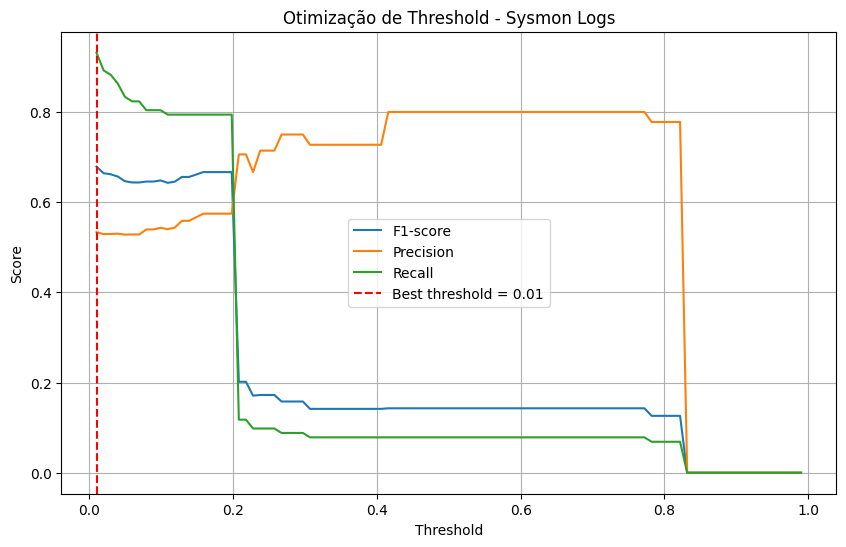

In [66]:
plt.figure(figsize=(10,6))

plt.plot(thresholds, f1_scores, label='F1-score')
plt.plot(thresholds, precision_scores, label='Precision')
plt.plot(thresholds, recall_scores, label='Recall')

plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')

plt.title("Otimização de Threshold - Sysmon Logs")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

Confusion matrix (rows=true, cols=pred) [0=benign,1=ransomware]:
 [[88  2]
 [94  8]]


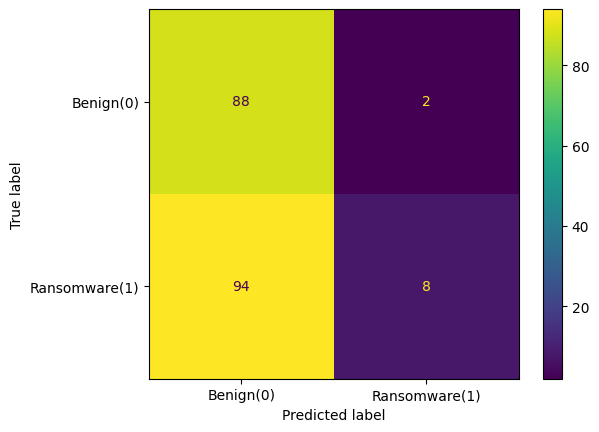

               precision    recall  f1-score   support

    Benign(0)       0.48      0.98      0.65        90
Ransomware(1)       0.80      0.08      0.14       102

     accuracy                           0.50       192
    macro avg       0.64      0.53      0.39       192
 weighted avg       0.65      0.50      0.38       192



In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

# Avaliação (0=benigno, 1=ransomware) no nível de processo
df_eval = df_logs[df_logs["Label"].isin([0, 1])].copy()
y_true = df_eval["Label"].astype(int).values

# pred_label pode ser {0, pos_label}; converte para {0,1}
y_pred = (df_eval["pred_label"] == pos_label).astype(int).values

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("Confusion matrix (rows=true, cols=pred) [0=benign,1=ransomware]:\n", cm)

disp = ConfusionMatrixDisplay(cm, display_labels=["Benign(0)", "Ransomware(1)"])
disp.plot(values_format="d")
plt.show()

print(classification_report(y_true, y_pred, target_names=["Benign(0)", "Ransomware(1)"]))

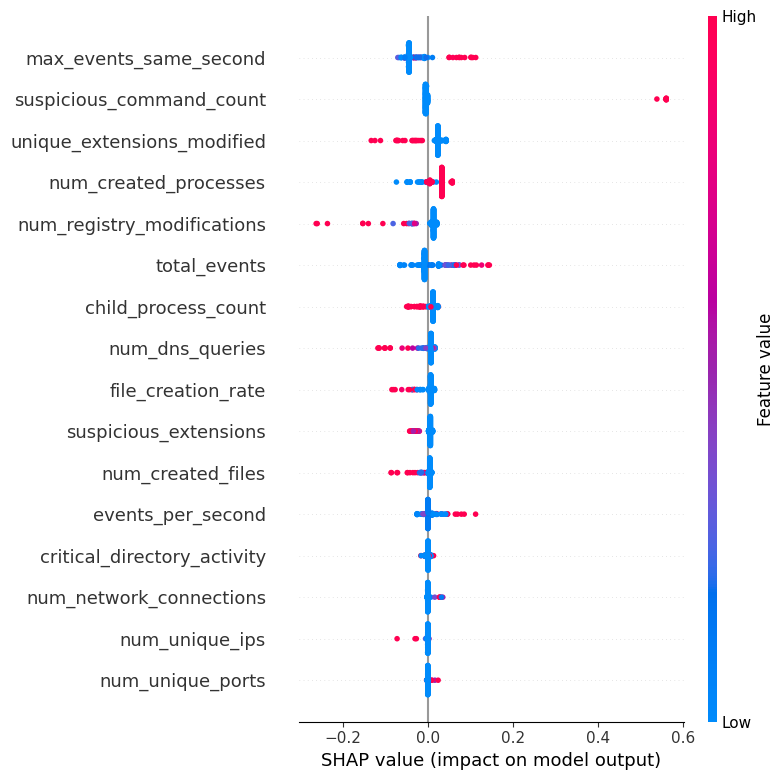

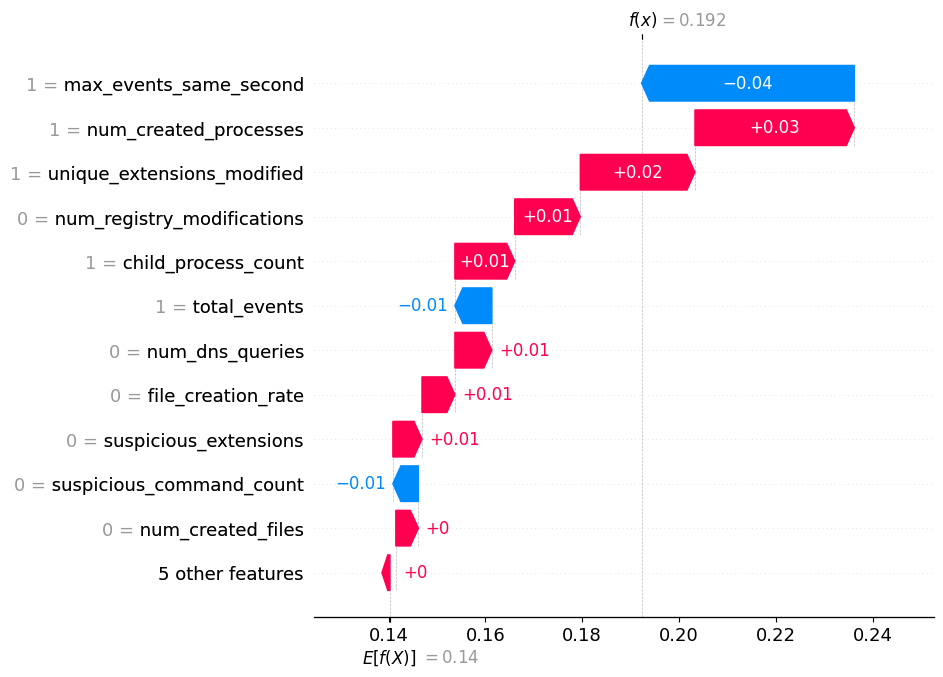

In [38]:
sample_logs = X_logs.sample(n=min(200, len(X_logs)), random_state=42)
train_sample = X_train.sample(n=min(5000, len(X_train)), random_state=42)

explainer = shap.TreeExplainer(rf, data=train_sample)
sv_all = explainer.shap_values(sample_logs)

if isinstance(sv_all, list):
    pos_index = classes.index(pos_label) if pos_label in classes else 0
    sv = sv_all[pos_index]
elif isinstance(sv_all, np.ndarray) and sv_all.ndim == 3:
    pos_index = classes.index(pos_label) if pos_label in classes else 0
    sv = sv_all[:, :, pos_index]
else:
    sv = sv_all

shap.summary_plot(sv, sample_logs, show=True)
plt.show()

instance_idx = 0
sv_row = sv[instance_idx] if hasattr(sv, "__getitem__") else np.array(sv)[instance_idx]
row = sample_logs.iloc[instance_idx]
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).ravel()
    base_value = float(base_value[pos_index]) if len(base_value) > pos_index else float(base_value[0])
else:
    base_value = float(base_value)

try:
    exp = shap.Explanation(
        values=sv_row,
        base_values=base_value,
        data=row.values,
        feature_names=sample_logs.columns.tolist(),
    )
    shap.plots.waterfall(exp, max_display=12)
    plt.show()
except Exception as e:
    print("waterfall failed:", e)

[('suspicious_command_count <= 0.00', -0.3417503991250743), ('max_events_same_second > 1.00', 0.10947957071846158), ('num_registry_modifications <= 0.00', 0.09069376784754622), ('1.00 < total_events <= 3.00', -0.08396865636898587), ('num_dns_queries > 0.00', -0.07626965688546176), ('file_creation_rate <= 0.00', 0.07302159487887212), ('unique_extensions_modified <= 1.00', 0.07197749529494088), ('suspicious_extensions <= 0.00', 0.048022799049599885), ('child_process_count <= 1.00', 0.04584067124470117), ('num_network_connections <= 0.00', -0.039885031333048285)]


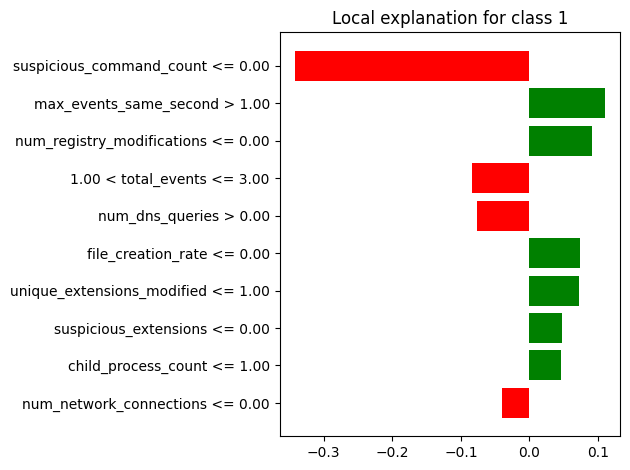

,feature,contribution
0,suspicious_command_count <= 0.00,-0.341750
1,max_events_same_second > 1.00,0.109480
2,num_registry_modifications <= 0.00,0.090694
3,1.00 < total_events <= 3.00,-0.083969
4,num_dns_queries > 0.00,-0.076270
5,file_creation_rate <= 0.00,0.073022
6,unique_extensions_modified <= 1.00,0.071977
7,suspicious_extensions <= 0.00,0.048023
8,child_process_count <= 1.00,0.045841
9,num_network_connections <= 0.00,-0.039885


In [39]:

# Garantir float
X_train = X_train.astype(float)
X_logs = X_logs.astype(float)

# Remover NaN e inf
X_train = X_train.replace([np.inf, -np.inf], 0).fillna(0)
X_logs = X_logs.replace([np.inf, -np.inf], 0).fillna(0)

instance_idx = 0
lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=[str(c) for c in classes],
    mode="classification",
)

exp = lime_explainer.explain_instance(
    X_logs.iloc[instance_idx].values,
    rf.predict_proba,
    num_features=10,
)

print(exp.as_list())
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

df_lime = pd.DataFrame(exp.as_list(), columns=["feature", "contribution"])
df_lime

In [40]:
# Checagem de linhas com pred_label=pos_label (ransomware)
if "pred_label" in df_logs.columns:
    ransomware_count = int((df_logs["pred_label"] == pos_label).sum())
    total_count = int(len(df_logs))
    print(f"ransomware_count: {ransomware_count} / {total_count}")
    if ransomware_count == 0:
        print("Nenhuma linha com pred_label=1 no df_logs.")
else:
    print("pred_label column not found in df_logs")


ransomware_count: 171 / 192
